<a href="https://colab.research.google.com/github/helloohowareyu/Praktikum-Kecerdasan-Artifisial-Lanjut/blob/main/BAB12_LC_NAMA_NIM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Live Coding BAB 12 Association Rule**

- Nama    : Achmad Yusuf Hamdani Firmansyah
- NIM     : 245150207111084
- Kelas   : E

##**Deskripsi**

MOG ingin meningkatkan penjualan dengan membuat paket promosi berdasarkan kebiasaan pembelian pelanggan. Toko tersebut memiliki data historis transaksi berupa item-item yang dibeli setiap pelanggan dalam satu transaksi. Untuk mengidentifikasi kombinasi produk yang sering dibeli bersamaan, tim analisis menggunakan pendekatan Association Rule Mining sehingga dapat dibuat sebagai paket bundling atau diskon gabungan sebagai salah satu strategi bisnis.

## **1. Import Library**

In [11]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*utcnow().*")

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules

## **2. Load and Exploratory Dataset**
*(tambah code cell sesuai kebutuhan Anda)*

In [13]:
url = 'https://raw.githubusercontent.com/helloohowareyu/Praktikum-Kecerdasan-Artifisial-Lanjut/refs/heads/main/LC%2012/groceries.csv'
df = pd.read_csv(url)

In [14]:
df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [15]:
df.describe()

,Member_number
count,38765.000000
mean,3003.641868
std,1153.611031
min,1000.000000
25%,2002.000000
50%,3005.000000
75%,4007.000000
max,5000.000000


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB


## **3. Preprocessing**
*(tambah code cell sesuai kebutuhan Anda)*

### **a. Cek Null Values**

In [17]:
df.isnull().sum()

,0
Member_number,0
Date,0
itemDescription,0


### **b. One-Hot Encoding**
*Pilih 2 fitur yang relevan dan lakukan one hot encode*

In [19]:
basket = pd.crosstab(index=[df['Member_number'], df['Date']], columns=df['itemDescription'])

In [20]:
basket_sets = basket.applymap(lambda x: 1 if x > 0 else 0)

/tmp/ipykernel_2355/1328208419.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_sets = basket.applymap(lambda x: 1 if x > 0 else 0)


## **4. Association Rule Mining (ARM)**
*(tambah code cell sesuai kebutuhan Anda)*

### **a. Apriori**
*min_support: 0.01*

In [21]:
frequent_itemsets = apriori(basket_sets, min_support=0.01, use_colnames=True)

In [22]:
print(frequent_itemsets.head())

    support        itemsets
0  0.021386      (UHT-milk)
1  0.033950          (beef)
2  0.021787       (berries)
3  0.016574     (beverages)
4  0.045312  (bottled beer)


### **b. Confidence-based Association Rules**
*min_threshold: 0.01*

In [24]:
rules_conf = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.01)

In [35]:
# Sort berdasarkan confidence
rules_conf = rules_conf.sort_values(by='confidence', ascending=False)

In [36]:
# Tampilkan antecedent, consequents, support, confidence dan lift untuk top 10 rules_conf
top10 = rules_conf[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)
top10

,antecedents,consequents,support,confidence,lift
8,(yogurt),(whole milk),0.011161,0.129961,0.822940
4,(rolls/buns),(whole milk),0.013968,0.126974,0.804028
2,(other vegetables),(whole milk),0.014837,0.121511,0.769430
6,(soda),(whole milk),0.011629,0.119752,0.758296
0,(rolls/buns),(other vegetables),0.010559,0.095990,0.786154
3,(whole milk),(other vegetables),0.014837,0.093948,0.769430
5,(whole milk),(rolls/buns),0.013968,0.088447,0.804028
1,(other vegetables),(rolls/buns),0.010559,0.086481,0.786154
7,(whole milk),(soda),0.011629,0.073635,0.758296
9,(whole milk),(yogurt),0.011161,0.070673,0.822940


### **c. Lift-based Association Rules**
*min_threshold=0.5*

In [28]:
rules_lift = association_rules(frequent_itemsets, metric="lift", min_threshold=0.5)

In [29]:
# Sort berdasarkan lift
rules_lift = rules_lift.sort_values('lift', ascending=False)

In [30]:
# Tampilkan antecedent, consequents, support, confidence dan lift untuk top 10 rules_lift
top10 = rules_lift[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)
top10

,antecedents,consequents,support,confidence,lift
9,(whole milk),(yogurt),0.011161,0.070673,0.822940
8,(yogurt),(whole milk),0.011161,0.129961,0.822940
5,(whole milk),(rolls/buns),0.013968,0.088447,0.804028
4,(rolls/buns),(whole milk),0.013968,0.126974,0.804028
1,(other vegetables),(rolls/buns),0.010559,0.086481,0.786154
0,(rolls/buns),(other vegetables),0.010559,0.095990,0.786154
2,(other vegetables),(whole milk),0.014837,0.121511,0.769430
3,(whole milk),(other vegetables),0.014837,0.093948,0.769430
7,(whole milk),(soda),0.011629,0.073635,0.758296
6,(soda),(whole milk),0.011629,0.119752,0.758296


## **5. Visualization**
Visualisasikan Top 10 Rules untuk setiap metrics menggunakan barplot, dimana x=metric-nya dan y=rule (sudah diberikan dibawah)

### **a. Confidence-based Rules**

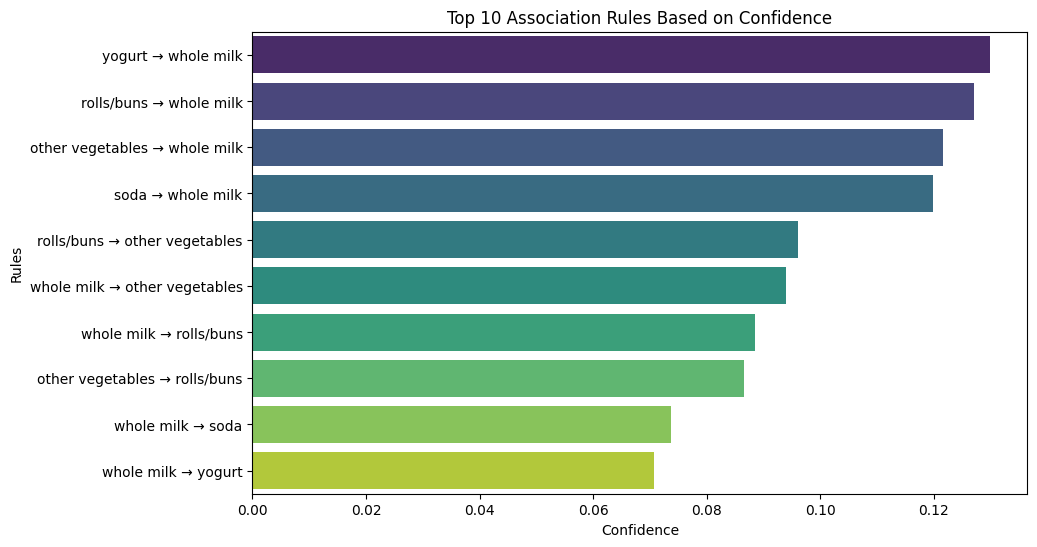

In [34]:
rules_conf['rule'] = rules_conf['antecedents'].apply(lambda x: ', '.join(list(x))) + " → " + \
                rules_conf['consequents'].apply(lambda x: ', '.join(list(x)))

top10 = rules_conf.head(10)

# Buat disini
plt.figure(figsize=(10, 6))
sns.barplot(x='confidence', y='rule', data=top10, hue='rule', palette='viridis', legend=False)
plt.title('Top 10 Association Rules Based on Confidence')
plt.xlabel('Confidence')
plt.ylabel('Rules')
plt.show()


### **b. Lift-based Rules**

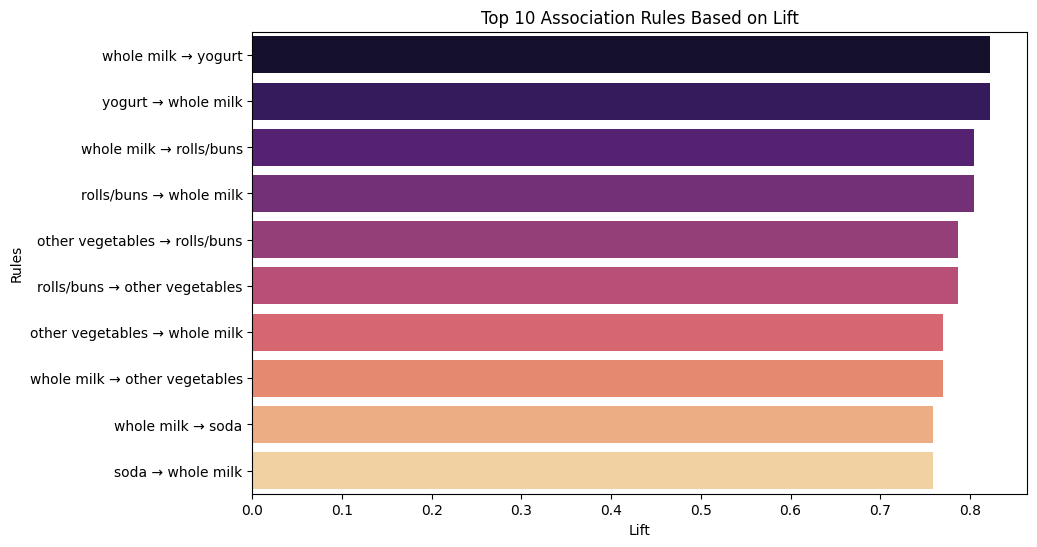

In [33]:
rules_lift['rule'] = rules_lift['antecedents'].apply(lambda x: ', '.join(list(x))) + " → " + \
                rules_lift['consequents'].apply(lambda x: ', '.join(list(x)))

top10 = rules_lift.head(10)

# Buat disini
plt.figure(figsize=(10, 6))
sns.barplot(x='lift', y='rule', data=top10, hue='rule', palette='magma', legend=False)
plt.title('Top 10 Association Rules Based on Lift')
plt.xlabel('Lift')
plt.ylabel('Rules')
plt.show()

## **6. Analisis**
1. Apa aturan/rules tertinggi untuk masing-masing metrik? Jelaskan makna kedua rules tersebut menggunakan bahasa manusia!

**Jawaban:**

Metrick Confidence tertinggi ada pada yogurt → whole milk dengan nilai confidence sekitar 0,1299 atau sekitar 13%. Artinya seluruh transaksi pelanggan yang beli yogurt, sekitar 13% diantaranya pasti juga membeli whole milk (susu murni) dalam transaksi yang sama.

Sedangkan Metrick Lift tertinggi ada pada whole milk → yogurt dan yogurt → whole milk yang sama dengan nilai lift sekitar 0,8229. Artinya seluruh transaksi pelanggan yang membeli yogurt justru lebih jarang membeli whole milk dibandingkan dengan pelanggan biasa secara acak, kedua barang ini jarang dibeli bersamaan secara sengaja.

2. Berdasarkan visualisasi yang telah dibuat, apa karakteristik serta kelebihan dan kekurangan dari masing-masing metrik?


**Jawaban:**

Metrik Confidence

Kelebihan:
1. Sangat mudah dipahami oleh tim bisnis karena menunjukkan persentase kepastian
2. Membantu toko mengetahui produk apa yang hampir pasti dicari pelanggan setelah mereka mengambil produk tertentu

Kekurangan:
1. Metriknya satu arah, dimana nilai yogurt → whole milk berbeda jauh dengan yogurt → whole milk
2. Metrik ini mengabaikan seberapa populer item dikanan, produk apapun yang ditaruh disebelah kiri, kemungkinan besar menghasilkan nilai confidence yang tinggi ke whole milk

Metrik Lift

Kelebihan:
1. Lift memperhitungkan popularitas dari kedua barang (antecedent dan consequent)
2. Nilai Lift untuk yogurt → whole milk akan persis sama dengan whole milk → yogurt

Kekkurangan:
1. Angkanya bukan presentase langsung, jadi butuh pemahaman teoritis untuk menjelaskan ke orang awam atau pemilik bisnis
2. Kadang-kadang produk yang sangat jarang dibeli tetapi kebetulan muncul bersamaan sekali atau dua kali bisa menghasilkan lift yang lemonjak tinggi, padahal polanya tidak merepresentasikan mayoritas pelanggan



3. Visualisasikan distribusi nilai support, confidence, dan lift dari rules_lift!

**Jawaban:**



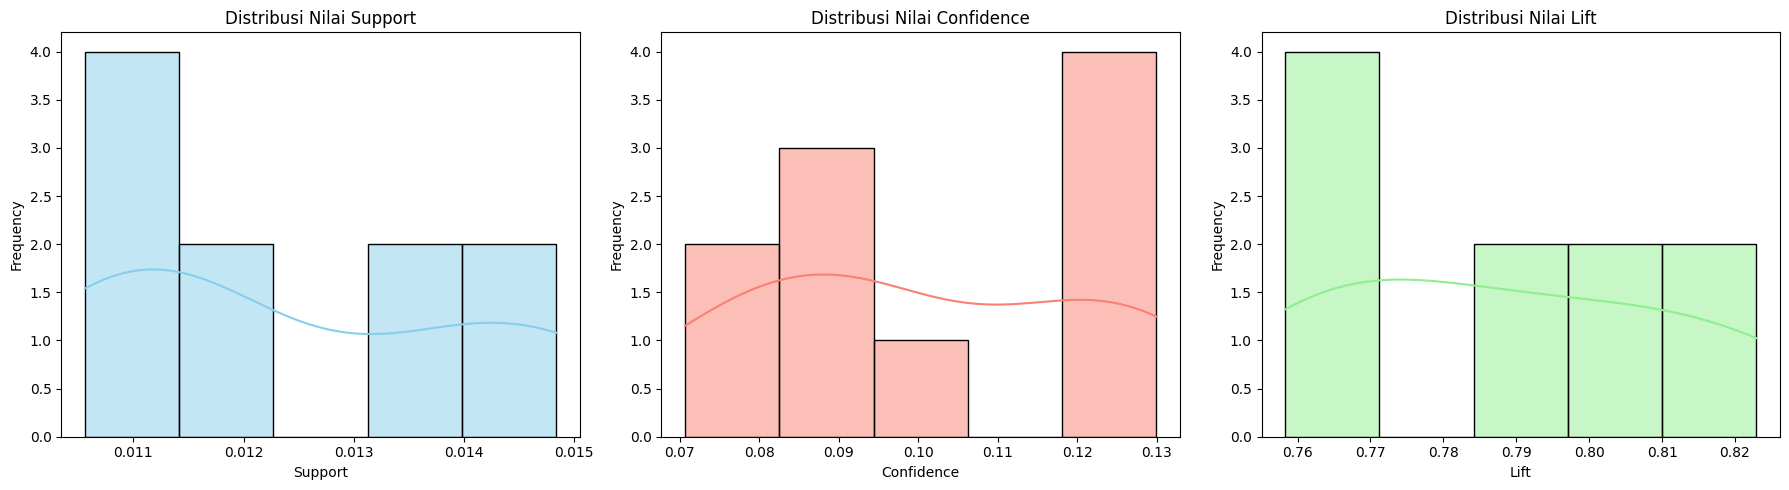

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribusi Support
sns.histplot(rules_lift['support'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Nilai Support')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Frequency')

# 2. Distribusi Confidence
sns.histplot(rules_lift['confidence'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribusi Nilai Confidence')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Frequency')

# 3. Distribusi Lift
sns.histplot(rules_lift['lift'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribusi Nilai Lift')
axes[2].set_xlabel('Lift')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

4. Berdasarkan distribusi tersebut, tentukan threshold untuk masing-masing nilai support, confidence, dan lift yang menurut Anda masuk akal serta relevan untuk strategi bisnis. Sertakan alasannya! *(note: tidak ada jawaban pasti, namun semakin kuat alasannya, semakin bagus poin nilainya)*

**Jawaban:**

Threshold Support di angka 0.011 (1.1%)

Nilai 0.011 berarti kombinasi barang tersebut setidaknya muncul di 1.1% dari total seluruh transaksi toko, untuk ukuran toko retail/groceries dengan ribuan variasi produk unik, angka 1.1% untuk sebuah kombinasi spesifik sudah cukup signifikan dan valid untuk dijadikan sampel promosi

Threshold Confidence 0.09 (9%)

Nilai 9% ini berarti dari seluruh orang yang membeli produk A, ada kepastian sebesar 9% bahwa mereka juga akan mengambil produk B. Kita bisa nantinya menangkap aturan produk lain yang memiliki potensi bisnis tinggi namun belum tersorot

Threshold Lift 0.80

Angka ini diambil untuk menyaring kombinasi produk yang paling mendekati nilai independen , pola di bawah 0.80 harus dibuang karena produknya benar-benar saling menggantikan sehingga mustahil untuk dibundling

5. Lakukan filtering pada rules_lift menggunakan threshold tersebut!


In [38]:
filtered_rules = rules_lift[
    (rules_lift['support'] >= 0.011) &
    (rules_lift['confidence'] >= 0.09) &
    (rules_lift['lift'] >= 0.80)
]

filtered_rules = filtered_rules.sort_values(by='lift', ascending=False)

filtered_rules[['rule', 'support', 'confidence', 'lift']]

,rule,support,confidence,lift
8,yogurt → whole milk,0.011161,0.129961,0.822940
4,rolls/buns → whole milk,0.013968,0.126974,0.804028


6. Berdasarkan hasil filter pada no.5, buatlah 2 rekomendasi paket bundling produk yang memiliki potensi untuk dipromosikan. (misalkan paket hemat: A + B + C atau beli produk A dan B → dapat diskon produk C)

**Jawaban:**

Paket 1 (Yogurt + Whole Milk)

Mekanismenya beli yogurt, dapat diskon potongan harga untuk whole milk

Paket 2 (Rools/Buns + Whole Milk)

Paket Bundling dengan harga paket tunggal yang lebih murah ketimbang beli satuan